In [12]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim 
from torch.utils.data import TensorDataset, DataLoader 
# 데이터 로드
iris = load_iris()
X, y = iris.data , iris.target
print(f"전체 데이터: {X.shape[0]}개, 특성 {X.shape[1]}개, 종류 {len(set(y))}개")
print(f"종 이름: {iris.target_names.tolist()}")

# 학습/테스트 분리 (80:20)
x_train_full,x_test,y_train_full,y_test = train_test_split(X,y, random_state=42, test_size=0.2)
x_train,x_val,y_train,y_val = train_test_split(x_train_full,y_train_full, random_state=42, test_size=0.2)

# 정규화 (특성 스케일 통일)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
x_val = scaler.transform(x_val)

# 파이토치 텐서로 변환
x_train_t = torch.tensor(x_train, dtype=torch.float32)
x_test_t = torch.tensor(x_test, dtype=torch.float32)
x_val_t = torch.tensor(x_val, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)
y_val_t = torch.tensor(y_val, dtype=torch.long)

# DataLoader 구성 (미니배치 자동 관리)
train_dataset = TensorDataset(x_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size= 16, shuffle=True)

print(f"\n학습 데이터: {len(x_train_t)}개, 검증 데이터 : {len(x_val)}개, 테스트 데이터: {len(x_test_t)}개")
print(f"미니배치 크기: 16, 에폭당 반복 횟수: {len(train_loader)}")

전체 데이터: 150개, 특성 4개, 종류 3개
종 이름: ['setosa', 'versicolor', 'virginica']

학습 데이터: 96개, 검증 데이터 : 24개, 테스트 데이터: 30개
미니배치 크기: 16, 에폭당 반복 횟수: 6


In [13]:
class IrisClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(4, 16) # 입력 4개 특성 → 은닉 16개 뉴런
        self.layer2 = nn.Linear(16, 8) # 은닉 16 → 은닉 8
        self.layer3 = nn.Linear(8, 3) # 은닉 8 → 출력 3개 (3종 분류)

    def forward(self, x):
        x = torch.relu(self.layer1(x)) # 은닉층 1 (ReLU)
        x = torch.relu(self.layer2(x)) # 은닉층 2 (ReLU)
        x = self.layer3(x) # 출력층 (softmax는 CrossEntropyLoss 내부에서 자동 적용)
        return x

model_iris = IrisClassifier()
print(model_iris)
print(f'\n총 파라미터 수 : {sum( p.numel() for p in model_iris.parameters())}')

IrisClassifier(
  (layer1): Linear(in_features=4, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=8, bias=True)
  (layer3): Linear(in_features=8, out_features=3, bias=True)
)

총 파라미터 수 : 243


In [14]:
#
criterion =  nn.CrossEntropyLoss() # 로직 값을 갖고 있음
optimizer = optim.Adam(model_iris.parameters(), lr=1e-2)

In [15]:
epochs = 100
epoch_losses, epoch_val_losses = [], []
epoch_acces , epoch_val_acces = [],[]

for epoch in range(epochs):
    epoch_loss = 0.0
    epoch_acc = 0.0

    for batch_X, batch_y in train_loader:     # DataLoader가 미니배치를 자동 제공
      # ① Forward
      predictions = model_iris(batch_X)
      # ② Loss
      loss = criterion(predictions, batch_y)
      # ③ Zero Grad
      optimizer.zero_grad()
      # ④ Backward
      loss.backward()
      # ⑤ Step
      optimizer.step()
      epoch_loss += loss.item()
      
      acc = torch.softmax(predictions,axis=1)
      _,class_index = torch.max(acc,dim=1)
      acc = sum(class_index == batch_y) / len(batch_y)
      epoch_acc+= acc.item()

    avg_acc = epoch_acc / len(train_loader)
    epoch_acces.append(avg_acc)

    avg_loss = epoch_loss / len(train_loader)
    epoch_losses.append(avg_loss)




    with torch.no_grad():
      val_predict = model_iris(x_val_t)
      val_loss = criterion(val_predict, y_val_t).item()
      epoch_val_losses.append(val_loss)

      _, val_acc_index = torch.max(torch.softmax(val_predict, axis=1), dim=1)
      val_acc = sum(val_acc_index == y_val_t) / len(y_val_t)
      epoch_val_acces.append(val_acc)


    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1:3d}/{epochs}] \
        - 평균 Loss: {avg_loss:.4f} val loss {val_loss:.4f} \
        - 평균 ACC: {avg_acc:.4f} "
        )

Epoch [ 20/100]         - 평균 Loss: 0.0302 val loss 0.2405         - 평균 ACC: 1.0000 
Epoch [ 40/100]         - 평균 Loss: 0.0104 val loss 0.4065         - 평균 ACC: 1.0000 
Epoch [ 60/100]         - 평균 Loss: 0.0062 val loss 0.5946         - 평균 ACC: 1.0000 
Epoch [ 80/100]         - 평균 Loss: 0.0023 val loss 0.6422         - 평균 ACC: 1.0000 
Epoch [100/100]         - 평균 Loss: 0.0015 val loss 0.6844         - 평균 ACC: 1.0000 


테스트 정확도: 96.7% (29/30)


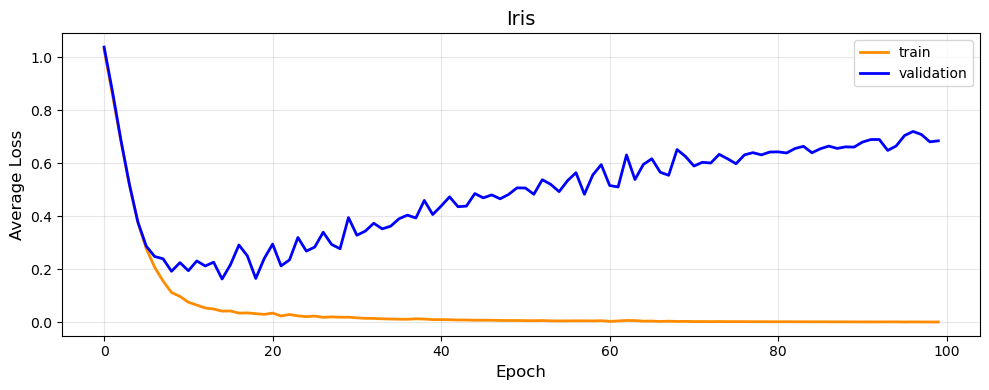

In [16]:
model_iris.eval()
# 평가 모드: 기울기 계산 불필요 (메모리 절약)
with torch.no_grad():
    test_outputs = model_iris(x_test_t)
    _, predicted = torch.max(test_outputs, dim=1) # 가장 높은 확률의 클래스 선택

    correct = (predicted == y_test_t).sum().item()
    total = y_test_t.size(0)
    accuracy = correct / total * 100

print("=" * 50)
print(f"테스트 정확도: {accuracy:.1f}% ({correct}/{total})")
print("=" * 50)

import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.plot(epoch_losses, color='darkorange', linewidth=2, label='train')
plt.plot(epoch_val_losses, color='blue', linewidth=2 , label='validation')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average Loss', fontsize=12)
plt.title('Iris', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

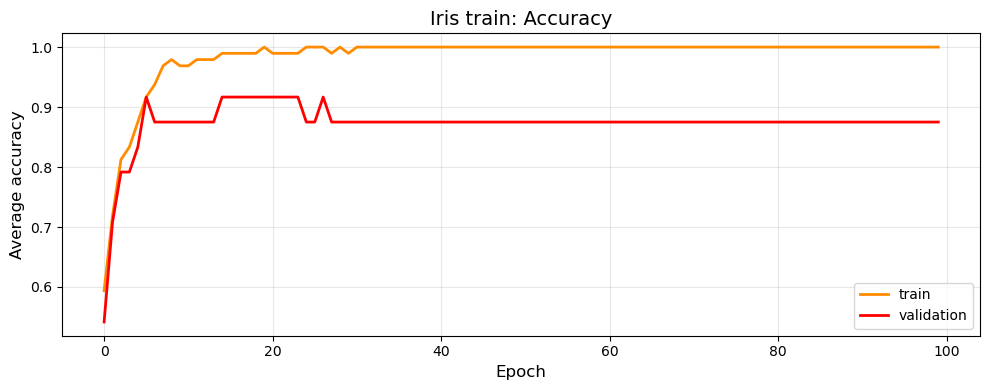

In [17]:
plt.figure(figsize=(10, 4))
plt.plot(epoch_acces, color='darkorange', linewidth=2, label='train')
plt.plot(epoch_val_acces, color='red', linewidth=2, label='validation')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average accuracy', fontsize=12)
plt.title('Iris train: Accuracy', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()